# 02 — Prompted Baseline

Reads `data/eval/prompted_baseline.csv` produced by `scripts/measure_prompted_baseline.py`
and summarises how well the **zero-shot PromptedCompiler** (Gemma-4-31B via OpenRouter)
performs on the 32 gold examples, broken down by harness rule.

**No API calls are made in this notebook.** Re-run freely.

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Resolve paths from repo root
_here = Path(os.path.abspath(''))
_root = _here.parent if _here.name == 'notebooks' else _here
os.chdir(_root)

CSV = Path('data/eval/prompted_baseline.csv')
assert CSV.exists(), f'Missing {CSV} — run scripts/measure_prompted_baseline.py first'

df = pd.read_csv(CSV)
df['final_passed'] = df['final_passed'].astype(bool)
print(f'Loaded {len(df)} rows from {CSV}')
df.head()

Loaded 32 rows from data/eval/prompted_baseline.csv


,doc_type,slug,n_blocks_gold,attempts,final_passed,total_failures,h1_failures,h2_failures,h3_failures,h4_failures,h5_failures,h6_failures,h7_failures,h8_failures,h9_failures,h10_failures,h11_failures,h12_failures,elapsed_seconds,error
0,memo,12-factor-app,21,1,True,0,0,0,0,0,0,0,0,0,0,0,0,0,79.85,NaN
1,memo,agile-manifesto,12,1,False,3,0,0,1,0,0,0,0,0,0,0,2,0,132.02,NaN
2,news,notre-dame-fire,8,1,True,0,0,0,0,0,0,0,0,0,0,0,0,0,16.31,NaN
3,memo,postmortem-doc,7,1,True,0,0,0,0,0,0,0,0,0,0,0,0,0,16.76,NaN
4,news,paris-2024-olympics,10,1,True,0,0,0,0,0,0,0,0,0,0,0,0,0,16.85,NaN


## 1. Overall pass rate

In [2]:
n_pass = df['final_passed'].sum()
n_total = len(df)
rate = n_pass / n_total
print(f'Prompted baseline: {rate:.0%} ({n_pass}/{n_total}) pass after up to 3 repair attempts')

n_errors = (df['error'].notna() & (df['error'] != '')).sum()
print(f'Rows with errors: {n_errors}/{n_total}')

Prompted baseline: 97% (31/32) pass after up to 3 repair attempts
Rows with errors: 0/32


## 2. Per-rule failure rate

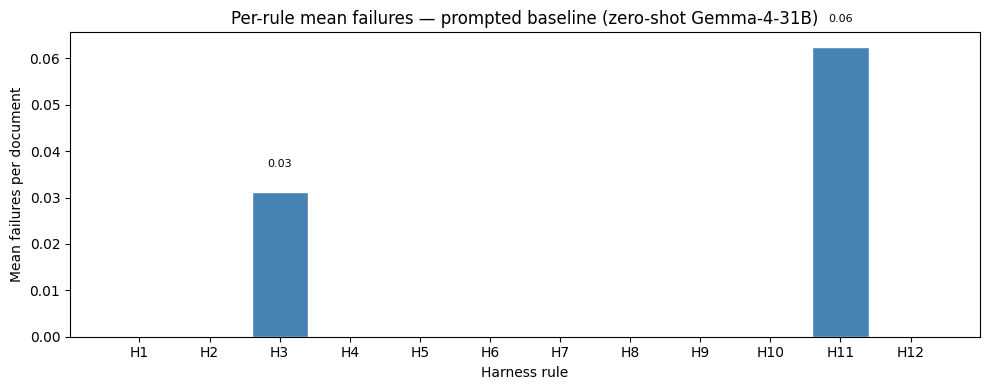

Chart saved to data/eval/rule_failures_baseline.png


In [3]:
RULES = [f'H{i}' for i in range(1, 13)]
rule_cols = [f'{r.lower()}_failures' for r in RULES]

# Mean failures per doc for each rule
rule_means = df[rule_cols].mean().rename(lambda c: c.replace('_failures', '').upper())

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(rule_means.index, rule_means.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Harness rule')
ax.set_ylabel('Mean failures per document')
ax.set_title('Per-rule mean failures — prompted baseline (zero-shot Gemma-4-31B)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
for bar, val in zip(bars, rule_means.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('data/eval/rule_failures_baseline.png', dpi=120)
plt.show()
print('Chart saved to data/eval/rule_failures_baseline.png')

## 3. Attempts distribution (passed vs failed)

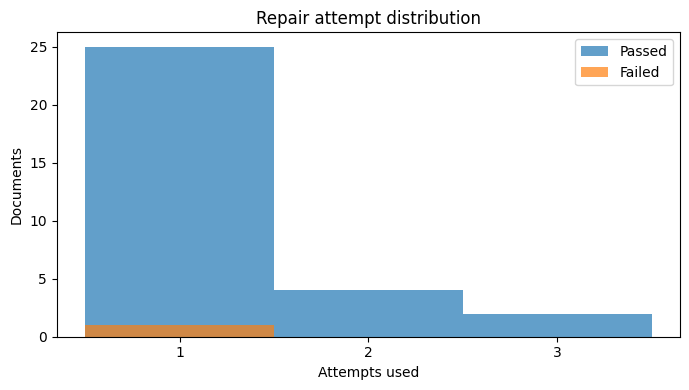

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, sub in [('Passed', df[df['final_passed']]), ('Failed', df[~df['final_passed']])]:
    if len(sub):
        ax.hist(sub['attempts'], bins=[0.5, 1.5, 2.5, 3.5], alpha=0.7, label=label)
ax.set_xlabel('Attempts used')
ax.set_ylabel('Documents')
ax.set_title('Repair attempt distribution')
ax.set_xticks([1, 2, 3])
ax.legend()
plt.tight_layout()
plt.show()

## 4. Top failure modes (ranked by mean failures per doc)

In [5]:
rule_summary = (
    rule_means
    .reset_index()
    .rename(columns={'index': 'rule', 0: 'mean_failures_per_doc'})
    .sort_values('mean_failures_per_doc', ascending=False)
    .reset_index(drop=True)
)
rule_summary['docs_affected'] = [
    (df[f'{r.lower()}_failures'] > 0).sum() for r in rule_summary['rule']
]
rule_summary['pct_docs_affected'] = (rule_summary['docs_affected'] / n_total * 100).round(1)
print(rule_summary.to_string(index=False))

rule  mean_failures_per_doc  docs_affected  pct_docs_affected
 H11                0.06250              1                3.1
  H3                0.03125              1                3.1
  H2                0.00000              0                0.0
  H1                0.00000              0                0.0
  H4                0.00000              0                0.0
  H5                0.00000              0                0.0
  H7                0.00000              0                0.0
  H6                0.00000              0                0.0
  H8                0.00000              0                0.0
  H9                0.00000              0                0.0
 H10                0.00000              0                0.0
 H12                0.00000              0                0.0


## 5. Per-doc-type pass rate

In [6]:
by_type = (
    df.groupby('doc_type')
    .agg(
        n=('slug', 'count'),
        n_pass=('final_passed', 'sum'),
        mean_failures=('total_failures', 'mean'),
    )
    .assign(pass_rate=lambda x: (x['n_pass'] / x['n']) * 100)
    .round(1)
    .sort_values('pass_rate')
)
print(by_type.to_string())

            n  n_pass  mean_failures  pass_rate
doc_type                                       
memo        5       4            0.6       80.0
news        4       4            0.0      100.0
other       5       5            0.0      100.0
paper       5       5            0.0      100.0
policy      4       4            0.0      100.0
report      5       5            0.0      100.0
transcript  4       4            0.0      100.0


## 6. Conclusion

In [7]:
top3 = rule_summary[rule_summary['mean_failures_per_doc'] > 0]['rule'].head(3).tolist()
top3_str = ', '.join(top3) if top3 else 'none'

summary = f"""## Prompted Baseline Summary

- **Overall pass rate**: {rate:.0%} ({n_pass}/{n_total} examples pass all 12 harness rules after up to 3 repair attempts)
- **Top 3 failure modes**: {top3_str}
- **Rows with API errors**: {n_errors}/{n_total}
- Phase 2 synthetic data filters should target: {top3_str}
"""
print(summary)

## Prompted Baseline Summary

- **Overall pass rate**: 97% (31/32 examples pass all 12 harness rules after up to 3 repair attempts)
- **Top 3 failure modes**: H11, H3
- **Rows with API errors**: 0/32
- Phase 2 synthetic data filters should target: H11, H3



---

## Conclusion

*(Filled in after notebook execution — see cell above for live numbers.)*

- Prompted baseline overall pass rate: see cell above
- Top 3 failure modes: see rule_summary table
- Phase 2 dataset filters should target these rules.